<a href="https://colab.research.google.com/github/tseringdorjee15/Intro-to-Machine-Learning--2026/blob/main/Titanic_dataset_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Titanic Dataset Analysis

From Kaggle: The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

In this challenge, we ask you to build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc).

# Tasks:



1.   Every step must have an explanation
2.   Every plot/ chart must have an iterpretation
3.   Add your observations for each section
4.   Draw clear conclusions (at least 5 conclusions)



In [150]:
import pandas as pd                  # Loads Pandas library: data manipulation tool used to clean, structure, & analyze tabular data
import matplotlib.pyplot as plt      # Loads foundational plotting library: used to create charts & graphs
import seaborn as sns                # Loads data visualization library built on top of matplotlib that makes clean, attractive statistical graphs

# A special command that forces charts to display directly below our code cells.
%matplotlib inline

# Loads the dataset by storing the raw web address of "Titanic dataset.csv" hosted on Github into text variable "url"
url = 'https://raw.githubusercontent.com/tseringdorjee15/Intro-to-Machine-Learning--2026/refs/heads/main/Titanic%20Dataset.csv'
train = pd.read_csv(url)             # Variable or dataframe "train" is used to store the dataset

# Display the first 5 rows
train.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# EDA (Exploratory Data Analysis)

In [151]:
import seaborn as sns

In [152]:
%matplotlib inline
import matplotlib.pyplot as plt

<Axes: >

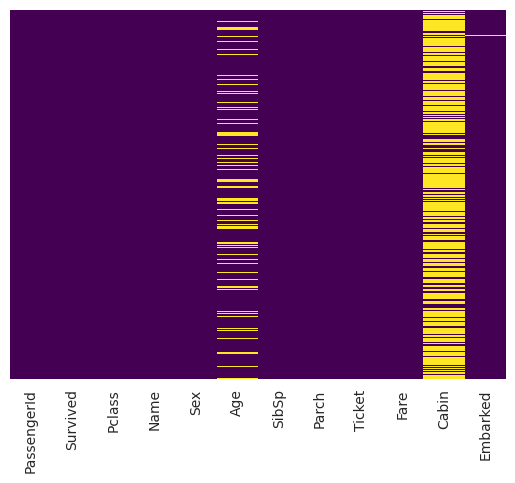

In [153]:
# The heatmap shows missing data (null values) in our dataset, where yellow bars represent missing values and purple areas represent complete data
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='viridis')

## Class
- In machine learning, predictive modeling, the categories we are trying to predict are called classes: either someone lived or died, our model has two classes: Class 0 (Did not survive) and Class 1 (Survived).An imbalance simply means one outcome (Class 0) has a lot more rows than the other (Class 1) in the following:
- (Class 0 - Did not survive) has a lot more rows than the other (Class 1 - survived).


<Axes: xlabel='Survived', ylabel='count'>

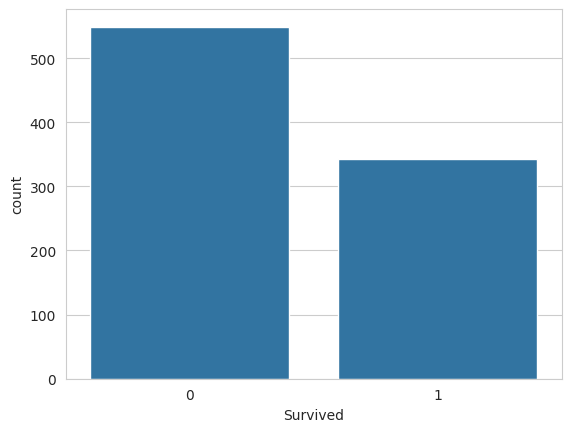

In [154]:
sns.set_style('whitegrid')                # Clean up the background of my chart
sns.countplot(x='Survived', data=train)   # checks our dataset & count how many people lived vs. died, and draw a bar chart of the results."

## Survived

<Axes: xlabel='Survived', ylabel='count'>

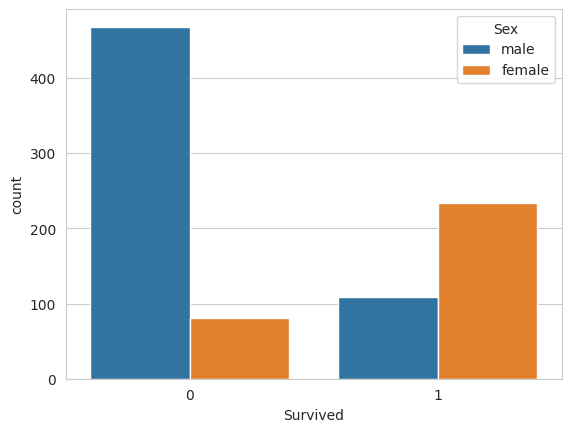

In [155]:
sns.set_style('whitegrid')                              # Clean up the background of my chart
sns.countplot(x='Survived', hue='Sex', data=train)      # x= 'Survived' broken down by 'sex', splitting each category into male and female.

## Pclass (Passenger Class)

<Axes: xlabel='Survived', ylabel='count'>

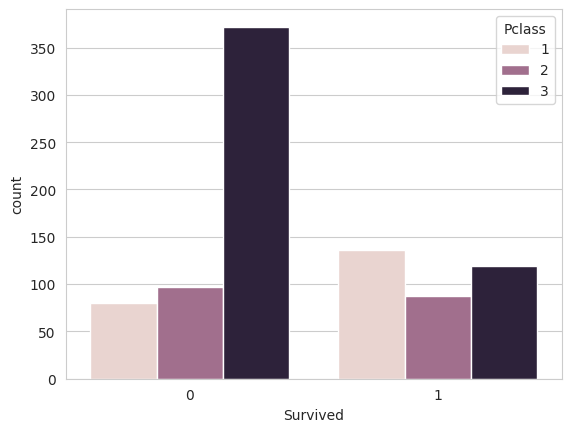

In [156]:
sns.set_style('whitegrid')                                     # Clean up the background of my chart
sns.countplot(x='Survived', hue='Pclass', data=train)          # x= 'Survived' broken down by 'Pclass', splitting each category into 'Pclass' : 1, 2, 3'.

## Age

/tmp/ipykernel_1706/2121817402.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Age'].dropna(), kde=False, bins=30)       # This code creates a histogram to show the distribution of passenger ages on the Titanic.


<Axes: xlabel='Age'>

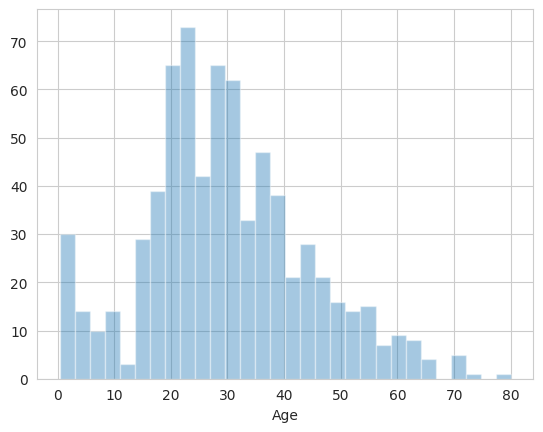

In [157]:
sns.distplot(train['Age'].dropna(), kde=False, bins=30)       # This code creates a histogram to show the distribution of passenger ages on the Titanic.
                                                              # temporarily drops all missing (null) values # Disables the continuous trend line   # Divides the age range (0 to 80 years old) into 30 equal blocks or intervals.

## Siblings

<Axes: xlabel='SibSp', ylabel='count'>

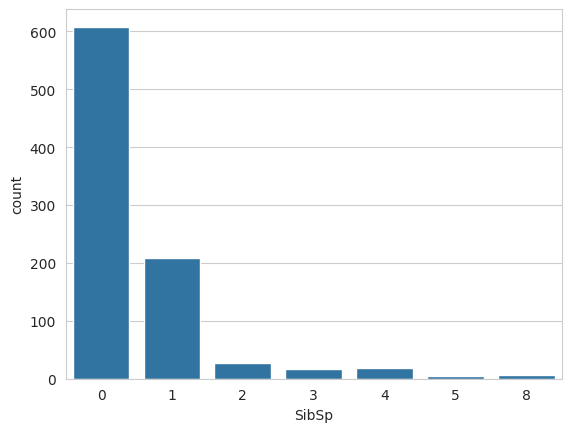

In [158]:
sns.countplot(x='SibSp',data=train)      # As per the official Kaggle Titanic dataset documentation: Count plot to visualize "Siblings or Spouses" columns where (0 = single), (1=couple), (2 to 8 = large families)

# Data Cleaning and Data Pre-Processing
- Transforms raw text data and missing fields into a clean, entirely numerical format that a machine learning model can understand

In [159]:
train.drop('Cabin', axis=1, inplace= True)     # Delete the entire Cabin column permanently as we saw in the yellow heatmap earlier, almost all of the Cabin data was missing, making it useless for training a model.

In [160]:
train.dropna(inplace=True)                     # Dropping Remaining Missing Rows that still has a blank space (like missing values in Age or Embarked) and delete that entire row

In [161]:
sex = pd.get_dummies(train['Sex'], drop_first=True)     # Converting Text to Numbers (Machine learning algorithms cannot read text like "male", "female", or "S". This converts them into numbers.)
                                                        # drop_first=True: instead of two columns for male and female, it creates a single column: male (where 1 means male and 0 means female).
embark = pd.get_dummies(train['Embarked'], drop_first=True)

In [162]:
train.drop(['Sex','Embarked','Name','Ticket'], axis=1, inplace= True)  # Delete the original text columns AND converted 'Sex' and 'Embarked' into numerical variables, 'Name' and 'Ticket' contain unique text strings that a standard model cannot use.

In [163]:
train.head()          # Displays final table of top 5 rows consisting entirely of numbers, ready for a machine learning algorithm.

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


In [164]:
# Successfully glues newly created columns back onto main table and displays the final dataset.
train = pd.concat([train, sex, embark],axis=1)     # "pd.concat([...])" = It acts like tape, joining separate blocks of data together. "axis=1": to stack these blocks side-by-side (as columns) rather than on top of each other (as rows).

In [165]:
train.head()    # Displays top 5 rows

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,0,3,22.0,1,0,7.2500,True,False,True
1,2,1,1,38.0,1,0,71.2833,False,False,False
2,3,1,3,26.0,0,0,7.9250,False,False,True
3,4,1,1,35.0,1,0,53.1000,False,False,True
4,5,0,3,35.0,0,0,8.0500,True,False,True


# Model building

> 1) **SPLITTING THE DATASET:** "**TRAINING SET**" & "**TEST SET**"



In [166]:
# TRAIN TEST SPLIT

from sklearn.model_selection import train_test_split   # imports the Logistic Regression algorithm from the scikit-learn library so we can use it to build and train our classification model.

In [167]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    train.drop('Survived', axis=1),                       # Creates feature "X" & DROPS the column we want to predict which is "Survived, so the model doesn't cheat"
    train['Survived'],                                    # This creates your target labels (y)— whether a passenger lived (1) or died (0).
    test_size=0.3,                                        # It reserves 30% of the data for testing our model's accuracy later, using 70% to train it.
    random_state=101                                      # It ensure that we get the exact same data split every time we run the code.
)


> 2) **TRAINING THE MODEL:**




In [168]:
from sklearn.linear_model import LogisticRegression

In [169]:
# initializes Logistic Regression algorithm and trains it on prepared dataset.

logmodel = LogisticRegression()      # This initializes a blank Logistic Regression object and saves it under the variable name logmodel
                                     # At this stage, the model is like a blank slate and doesn't know anything about the Titanic data.

logmodel.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

> 3) **MAKING PREDICTIONS:**


In [170]:
# Uses trained model to make predictions on the unseen test data.
predict = logmodel.predict(X_test)                  # logmodel: our trained Logistic Regression model object
                                                    # already gone through the .fit() process, meaning it has learned the patterns, weights, and mathematical formulas connecting passenger features to their survival chances.

## Classification report

In [171]:
from sklearn.metrics import classification_report    # Module within the Scikit-Learn library that contains tools to measure model performance  # X_test: This is the input argument for the method
                                                     # Specific function that calculates and formats EVALUATION SCORES (precision, recall, F1-Score, and Accuracy) all at once

In [172]:
print(classification_report(y_test, predict))        # Generate & Print the report where it shows: how well the machine learning model performed on the test data & achieved a solid overall accuracy of 76%
                                                    # 0.79: When model guessed someone died, it was right 79% of the time.
                                                    # 0.71: When it guessed someone survived, it was right 71% of the time.
                                                    # Recall: Out of all the passengers who actually belonged to a category, how many did the model successfully find?
                                                         # ==> 0.81: The model correctly identified 81% of the total people who died.
                                                         # ==> 0.69: The model only managed to catch 69% of the total people who survived.
                                                    # F1-Score: The balanced harmonic mean between precision and recall. Higher is better.
                                                    # Support: The actual headcount of passengers in your test set. There were 128 who died and 86 who survived (totaling 214 test passengers).

              precision    recall  f1-score   support

           0       0.79      0.81      0.80       128
           1       0.71      0.69      0.70        86

    accuracy                           0.76       214
   macro avg       0.75      0.75      0.75       214
weighted avg       0.76      0.76      0.76       214



## Confusion Matrix
### - This code generates a Confusion Matrix, which is a (2*2) grid that counts exactly how many correct and incorrect predictions your classification model made.

In [173]:
from sklearn.metrics import confusion_matrix         # IMPORT CONVUSION_MATRIX function is used to cross-reference actual outcomes against predicted outcomes.
print(confusion_matrix(y_test, predict))

[[104  24]
 [ 27  59]]


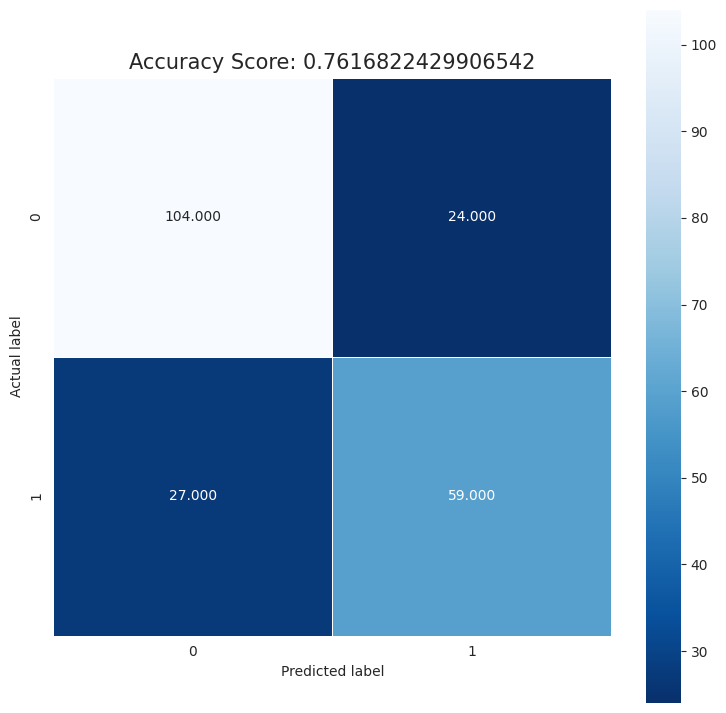

In [174]:
plt.figure(figsize=(9,9))                                                                                               # Sets up a square plotting window that is 9 inches wide by 9 inches tall.
sns.heatmap(confusion_matrix(y_test, predict), annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');  # creates a visual heatmap of your confusion matrix to make it much easier to read than a raw numbers array.
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(logmodel.score(X_test, y_test))                                         # calculates the accuracy score string and saves it into a variable called "all_sample_title"
plt.title(all_sample_title, size = 15);                                                                                 # to display that title, but notice the syntax typo:

In [175]:
from sklearn import  metrics

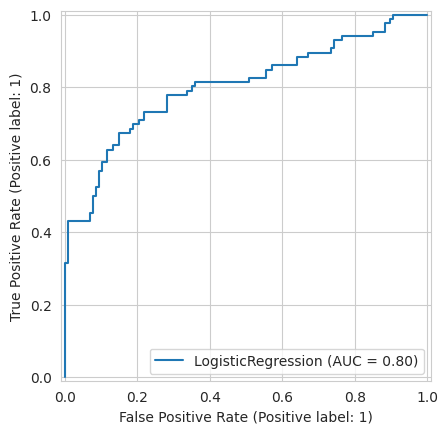

In [176]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# This is the modern replacement for plot_roc_curve
# Plots an ROC Curve (Receiver Operating Characteristic) to measure how well the model distinguishes between survivors and non-survivors across different decision thresholds.
RocCurveDisplay.from_estimator(logmodel, X_test, y_test)     # It passes test data (X_test) through a trained model (logmodel).Instead of a flat 0 or 1 guess, it grabs the raw mathematical percentage probability of survival for each passenger
                                                             #.It compares those percentages against the actual outcomes (y_test) to plot the blue line and calculate the AUC score (0.80).
plt.show()                                     # Render the final image onto the screen

Observation..

- The initial data exploration revealed that a majority of the passengers in the dataset did not survive (over 500 non-survivors vs. roughly 340 survivors).
- Demographic Biases: Survival rates were highly skewed by gender and socio-economic status.
- Females had a significantly higher chance of survival than males, and 1st class passengers had a much higher survival probability compared to 3rd class passengers.
- Missing Data: The Cabin column was missing too much data to be useful and had to be dropped, while the Age and Embarked columns contained minor missing values that required row cleaning.

# Conclusion...

**- Model Performance:** A Logistic Regression model was successfully trained on the cleaned numerical features, achieving a solid overall predictive accuracy of 76.17% on the unseen test dataset.

**- Classification Balance:** The model achieved an AUC score of 0.80, demonstrating strong capability in distinguishing between survivors and non-survivors.
**- However, the evaluation metrics shows: it is slightly better at correctly predicting non-survivors (79% precision) than survivors (71% precision).
- Final Takeaway: The high baseline accuracy confirms that historical passenger demographics (such as age, gender, and ticket class) hold exceptionally strong predictive power for determining survival outcomes in classification tasks.